# TSVD Regularization for Shack-Hartmann Wavefront Reconstruction

This notebook studies truncated singular value decomposition (TSVD) regularization for modal wavefront reconstruction.

The goal is to demonstrate the trade-off between:

- fitting high-order atmospheric wavefront structure,
- avoiding noise amplification,
- retaining stable singular directions,
- improving the residual wavefront RMS and Strehl ratio.

This notebook intentionally uses a more challenging reconstruction configuration:

- higher Zernike correction order,
- fewer Shack-Hartmann lenslets,
- non-zero slope measurement noise.

This makes the role of TSVD regularization more visible.

In [1]:
from pathlib import Path
import sys
import importlib

PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "zernike.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import zernike
import phase_screen
import reconstruction

importlib.reload(zernike)
importlib.reload(phase_screen)
importlib.reload(reconstruction)

from zernike import (
    make_pupil_grid,
    generate_zernike_modes,
)

from phase_screen import fourier_phase_screen

from reconstruction import (
    build_response_matrix,
    measure_slopes,
    residual_wavefront,
    rms,
)

In [3]:
def compute_psf_from_phase(phase_rad, mask, pad_factor=4):
    """
    Compute focal-plane PSF from pupil-plane phase.

    Parameters
    ----------
    phase_rad : ndarray
        Residual phase in radians.
    mask : ndarray
        Pupil mask.
    pad_factor : int
        Zero-padding factor for focal-plane sampling.

    Returns
    -------
    psf : ndarray
        Normalized PSF.
    """
    N = phase_rad.shape[0]

    pupil_field = np.zeros_like(phase_rad, dtype=complex)
    phase_clean = np.nan_to_num(phase_rad, nan=0.0)

    pupil_field[mask] = np.exp(1j * phase_clean[mask])

    pad_N = pad_factor * N
    padded = np.zeros((pad_N, pad_N), dtype=complex)

    start = (pad_N - N) // 2
    end = start + N

    padded[start:end, start:end] = pupil_field

    focal_field = np.fft.fftshift(
        np.fft.fft2(
            np.fft.ifftshift(padded)
        )
    )

    psf = np.abs(focal_field) ** 2
    psf /= np.sum(psf)

    return psf


def strehl_ratio(phase_rad, mask, pad_factor=4):
    """
    Compute approximate Strehl ratio.

    Strehl = peak aberrated PSF / peak diffraction-limited PSF
    """
    psf_aberrated = compute_psf_from_phase(
        phase_rad,
        mask,
        pad_factor=pad_factor,
    )

    psf_ideal = compute_psf_from_phase(
        np.zeros_like(phase_rad),
        mask,
        pad_factor=pad_factor,
    )

    return np.max(psf_aberrated) / np.max(psf_ideal)

In [4]:
# -------------------------
# Grid and atmosphere
# -------------------------
N = 256
diameter = 1.0

# -------------------------
# More challenging reconstruction setup
# -------------------------
max_radial_order = 16
n_lenslets = 10
noise_std = 0.10

# -------------------------
# Atmospheric phase-screen parameters
# -------------------------
r0 = 0.20
L0 = 25.0
atmosphere_seed = 4
target_rms_rad = 1.0

print("Simulation setup")
print("----------------")
print(f"N:                  {N}")
print(f"diameter:           {diameter}")
print(f"max_radial_order:   {max_radial_order}")
print(f"n_lenslets:         {n_lenslets}")
print(f"slope noise std:    {noise_std}")
print(f"r0:                 {r0}")
print(f"L0:                 {L0}")
print(f"target RMS phase:   {target_rms_rad} rad")

Simulation setup
----------------
N:                  256
diameter:           1.0
max_radial_order:   16
n_lenslets:         10
slope noise std:    0.1
r0:                 0.2
L0:                 25.0
target RMS phase:   1.0 rad


In [5]:
X, Y, rho, theta, mask, dx = make_pupil_grid(
    N=N,
    diameter=diameter,
)

W_atm, _, _, _ = fourier_phase_screen(
    N=N,
    delta=dx,
    r0=r0,
    L0=L0,
    diameter=diameter,
    seed=atmosphere_seed,
    target_rms_rad=target_rms_rad,
)

print(f"Atmospheric wavefront RMS: {rms(W_atm, mask):.4f} rad")

Atmospheric wavefront RMS: 0.9999 rad


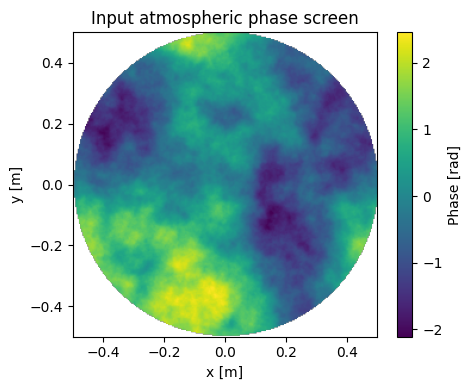

In [6]:
extent = [
    np.nanmin(X),
    np.nanmax(X),
    np.nanmin(Y),
    np.nanmax(Y),
]

plt.figure(figsize=(5, 4))

plt.imshow(
    W_atm,
    extent=extent,
    origin="lower",
)

plt.colorbar(label="Phase [rad]")
plt.title("Input atmospheric phase screen")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.tight_layout()
plt.show()

In [7]:
def reconstruct_wavefront_tsvd(
    slopes,
    response_matrix,
    modes,
    names,
    pupil_mask,
    rcond=1e-4,
):
    """
    Reconstruct wavefront using explicit truncated SVD.

    Keep singular directions satisfying:

        sigma_i > rcond * sigma_max

    This suppresses weakly sensed directions that would otherwise
    amplify measurement noise in the inverse reconstruction.
    """
    A = response_matrix
    s = slopes.reshape(-1)

    U, singular_values, Vt = np.linalg.svd(
        A,
        full_matrices=False,
    )

    cutoff = rcond * singular_values[0]
    keep = singular_values > cutoff

    inv_singular = np.zeros_like(singular_values)
    inv_singular[keep] = 1.0 / singular_values[keep]

    coeffs = Vt.T @ (inv_singular * (U.T @ s))

    W_rec = np.zeros_like(next(iter(modes.values())), dtype=float)

    for coeff, name in zip(coeffs, names):
        W_rec += coeff * np.nan_to_num(modes[name], nan=0.0)

    W_rec = np.where(pupil_mask, W_rec, np.nan)

    # Remove piston from reconstructed wavefront.
    W_rec[pupil_mask] -= np.nanmean(W_rec[pupil_mask])

    if np.sum(keep) > 0:
        condition_effective = singular_values[keep][0] / singular_values[keep][-1]
    else:
        condition_effective = np.inf

    info = {
        "singular_values": singular_values,
        "cutoff": cutoff,
        "keep": keep,
        "n_kept": int(np.sum(keep)),
        "n_total": len(singular_values),
        "condition_effective": condition_effective,
    }

    return coeffs, W_rec, info

In [8]:
def run_tsvd_reconstruction(
    W_true,
    X,
    Y,
    rho,
    theta,
    mask,
    max_radial_order=14,
    n_lenslets=14,
    noise_std=0.05,
    seed=1,
    rcond=1e-4,
):
    """
    Full Shack-Hartmann WFS reconstruction using TSVD regularization.
    """
    modes = generate_zernike_modes(
        rho,
        theta,
        mask,
        max_radial_order=max_radial_order,
        include_piston=False,
        normalization=True,
    )

    centers, slopes = measure_slopes(
        W_true,
        mask,
        X,
        Y,
        n_lenslets=n_lenslets,
        min_fill=0.5,
        noise_std=noise_std,
        seed=seed,
    )

    A, names, _ = build_response_matrix(
        modes,
        mask,
        X,
        Y,
        n_lenslets=n_lenslets,
        min_fill=0.5,
    )

    coeffs, W_rec, info = reconstruct_wavefront_tsvd(
        slopes,
        A,
        modes,
        names,
        mask,
        rcond=rcond,
    )

    res = residual_wavefront(W_true, W_rec, mask)

    S = strehl_ratio(
        res,
        mask,
        pad_factor=4,
    )

    return {
        "modes": modes,
        "names": names,
        "coeffs": coeffs,
        "centers": centers,
        "slopes": slopes,
        "A": A,
        "W_rec": W_rec,
        "residual": res,
        "residual_rms": rms(res, mask),
        "strehl": S,
        "info": info,
    }

In [9]:
test_result = run_tsvd_reconstruction(
    W_atm,
    X,
    Y,
    rho,
    theta,
    mask,
    max_radial_order=max_radial_order,
    n_lenslets=n_lenslets,
    noise_std=noise_std,
    seed=2,
    rcond=1e-8,
)

svals = test_result["info"]["singular_values"]
svals_norm = svals / svals[0]

print("Singular spectrum diagnostics")
print("-----------------------------")
print(f"Number of singular values:          {len(svals_norm)}")
print(f"Largest normalized singular value:  {svals_norm[0]:.4f}")
print(f"Smallest normalized singular value: {svals_norm[-1]:.4e}")
print(f"Condition number:                   {svals[0] / svals[-1]:.4e}")
print(f"Residual RMS with weak cutoff:      {test_result['residual_rms']:.4f} rad")
print(f"Strehl with weak cutoff:            {test_result['strehl']:.4f}")

Singular spectrum diagnostics
-----------------------------
Number of singular values:          152
Largest normalized singular value:  1.0000
Smallest normalized singular value: 4.3904e-08
Condition number:                   2.2777e+07
Residual RMS with weak cutoff:      34215.4373 rad
Strehl with weak cutoff:            0.0003


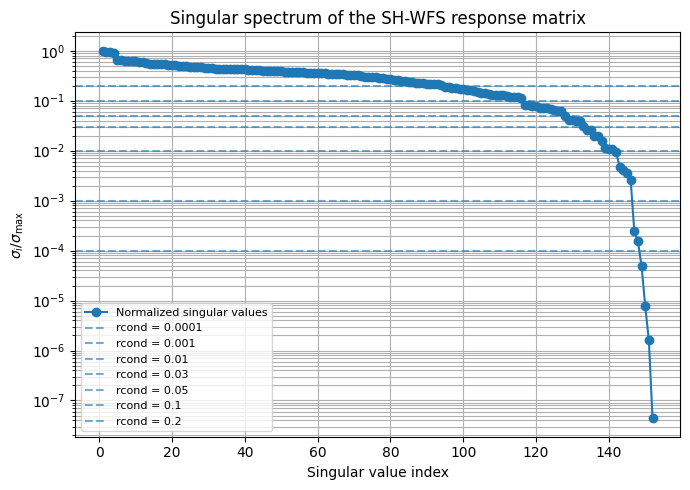

In [10]:
plt.figure(figsize=(7, 5))

plt.semilogy(
    np.arange(1, len(svals_norm) + 1),
    svals_norm,
    marker="o",
    label="Normalized singular values",
)

for rcond in [1e-4, 1e-3, 1e-2, 3e-2, 5e-2, 1e-1, 2e-1]:
    plt.axhline(
        rcond,
        linestyle="--",
        alpha=0.6,
        label=f"rcond = {rcond:g}",
    )

plt.xlabel("Singular value index")
plt.ylabel(r"$\sigma_i / \sigma_{\max}$")
plt.title("Singular spectrum of the SH-WFS response matrix")
plt.grid(True, which="both")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Singular-Value Spectrum of the SH-WFS Response Matrix

This plot shows the normalized singular-value spectrum of the Shack-Hartmann WFS response matrix. Each singular value represents how strongly one independent modal direction is sensed by the wavefront sensor.

In this stress-test configuration, the response matrix is highly ill-conditioned. It has 152 singular values, but the smallest normalized singular value is only approximately

$$
4.39 \times 10^{-8}.
$$

This corresponds to a condition number of approximately

$$
2.28 \times 10^{7}.
$$

Therefore, some modal combinations are extremely weakly sensed by the WFS. If these weak singular directions are directly inverted, even small slope-measurement errors can be strongly amplified in the reconstructed wavefront.

The horizontal dashed lines indicate different TSVD cutoff values. A singular direction is retained only if

$$
\frac{\sigma_i}{\sigma_{\max}} > \mathrm{rcond}.
$$

Thus, increasing `rcond` progressively removes the weakest and most noise-sensitive singular directions from the reconstruction.

### Meaning of the TSVD Cutoff `rcond`

The parameter `rcond` is a relative singular-value cutoff used in the SVD pseudo-inverse. A singular direction is retained only if

$$
\frac{\sigma_i}{\sigma_{\max}} > \mathrm{rcond}.
$$

A very small `rcond` keeps almost all singular directions. This maximizes the nominal number of corrected modes, but it also keeps extremely weak directions that can amplify measurement noise.

A larger `rcond` removes more weak singular directions. This improves numerical stability and suppresses noise amplification. However, if the cutoff becomes too large, physically useful modal directions are also removed.

Therefore, the best cutoff is expected to lie in an intermediate regime:

- too small `rcond`: noise amplification;
- intermediate `rcond`: optimal regularization;
- too large `rcond`: modal underfitting.

In [11]:
rcond_values = np.array([
    1e-8,
    1e-5,
    1e-4,
    1e-3,
    3e-3,
    1e-2,
    3e-2,
    5e-2,
    8e-2,
    1e-1,
    1.5e-1,
    2e-1,
    3e-1,
    5e-1,
])

tsvd_results = []

for rcond in rcond_values:
    result = run_tsvd_reconstruction(
        W_atm,
        X,
        Y,
        rho,
        theta,
        mask,
        max_radial_order=max_radial_order,
        n_lenslets=n_lenslets,
        noise_std=noise_std,
        seed=2,
        rcond=rcond,
    )

    tsvd_results.append(result)

    print(
        f"rcond={rcond:.2e}, "
        f"kept={result['info']['n_kept']:3d}/{result['info']['n_total']:3d}, "
        f"residual RMS={result['residual_rms']:.4f} rad, "
        f"Strehl={result['strehl']:.4f}, "
        f"effective cond={result['info']['condition_effective']:.2e}"
    )

rcond=1.00e-08, kept=152/152, residual RMS=34215.4373 rad, Strehl=0.0003, effective cond=2.28e+07
rcond=1.00e-05, kept=149/152, residual RMS=18.5940 rad, Strehl=0.0136, effective cond=2.05e+04
rcond=1.00e-04, kept=148/152, residual RMS=17.0123 rad, Strehl=0.0147, effective cond=6.57e+03
rcond=1.00e-03, kept=146/152, residual RMS=2.7298 rad, Strehl=0.2791, effective cond=3.87e+02
rcond=3.00e-03, kept=145/152, residual RMS=1.3199 rad, Strehl=0.3567, effective cond=2.78e+02
rcond=1.00e-02, kept=141/152, residual RMS=0.8526 rad, Strehl=0.6541, effective cond=9.41e+01
rcond=3.00e-02, kept=133/152, residual RMS=0.4733 rad, Strehl=0.8172, effective cond=3.21e+01
rcond=5.00e-02, kept=127/152, residual RMS=0.3762 rad, Strehl=0.8741, effective cond=1.62e+01
rcond=8.00e-02, kept=118/152, residual RMS=0.5970 rad, Strehl=0.8560, effective cond=1.24e+01
rcond=1.00e-01, kept=116/152, residual RMS=0.6062 rad, Strehl=0.8484, effective cond=8.65e+00
rcond=1.50e-01, kept=103/152, residual RMS=0.7897 rad,

In [12]:
residual_tsvd = np.array([
    r["residual_rms"] for r in tsvd_results
])

strehl_tsvd = np.array([
    r["strehl"] for r in tsvd_results
])

n_kept_tsvd = np.array([
    r["info"]["n_kept"] for r in tsvd_results
])

cond_eff_tsvd = np.array([
    r["info"]["condition_effective"] for r in tsvd_results
])

print("rcond values:")
print(rcond_values)

print("\nResidual RMS:")
print(residual_tsvd)

print("\nStrehl:")
print(strehl_tsvd)

print("\nNumber of kept singular directions:")
print(n_kept_tsvd)

print("\nEffective condition number:")
print(cond_eff_tsvd)

rcond values:
[1.0e-08 1.0e-05 1.0e-04 1.0e-03 3.0e-03 1.0e-02 3.0e-02 5.0e-02 8.0e-02
 1.0e-01 1.5e-01 2.0e-01 3.0e-01 5.0e-01]

Residual RMS:
[3.42154373e+04 1.85940005e+01 1.70122838e+01 2.72975638e+00
 1.31993842e+00 8.52555926e-01 4.73280282e-01 3.76163580e-01
 5.97031280e-01 6.06228264e-01 7.89730105e-01 8.56814177e-01
 9.42826904e-01 9.83933399e-01]

Strehl:
[2.97340183e-04 1.36169041e-02 1.47344838e-02 2.79131231e-01
 3.56724650e-01 6.54051951e-01 8.17236767e-01 8.74066686e-01
 8.56046534e-01 8.48424246e-01 6.60924172e-01 6.03736052e-01
 5.07274330e-01 4.68227876e-01]

Number of kept singular directions:
[152 149 148 146 145 141 133 127 118 116 103  94  74  22]

Effective condition number:
[2.27767386e+07 2.05368456e+04 6.56693793e+03 3.87324993e+02
 2.77918494e+02 9.41468599e+01 3.21096204e+01 1.62063556e+01
 1.24477312e+01 8.64713947e+00 6.44788586e+00 4.79813514e+00
 3.32191086e+00 1.99641257e+00]


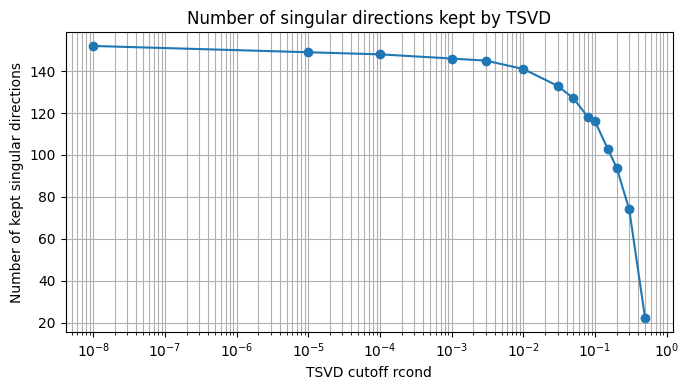

In [13]:
plt.figure(figsize=(7, 4))

plt.semilogx(
    rcond_values,
    n_kept_tsvd,
    marker="o",
)

plt.xlabel("TSVD cutoff rcond")
plt.ylabel("Number of kept singular directions")
plt.title("Number of singular directions kept by TSVD")
plt.grid(True, which="both")
plt.tight_layout()
plt.show()

### Number of Kept Singular Directions

This plot shows how many singular directions are retained as the TSVD cutoff `rcond` is increased.

For very small cutoff values, nearly all singular directions are kept. For example, at

$$
\mathrm{rcond} = 10^{-8},
$$

all 152 singular directions are retained. However, this also includes extremely weak and noise-sensitive directions.

As `rcond` is increased, TSVD removes more weakly sensed modal directions. At the optimal cutoff

$$
\mathrm{rcond} = 5 \times 10^{-2},
$$

127 out of 152 singular directions are kept. This means that 25 weak singular directions have been removed from the inverse problem.

At very large cutoffs, the truncation becomes too aggressive. For example, at

$$
\mathrm{rcond} = 5 \times 10^{-1},
$$

only 22 singular directions are retained. This is no longer a balanced regularization regime, but an underfit reconstruction with too few degrees of freedom.

The key point is that retaining more singular directions is not always better. In an ill-conditioned inverse problem, some retained directions may contribute more noise amplification than useful wavefront information.

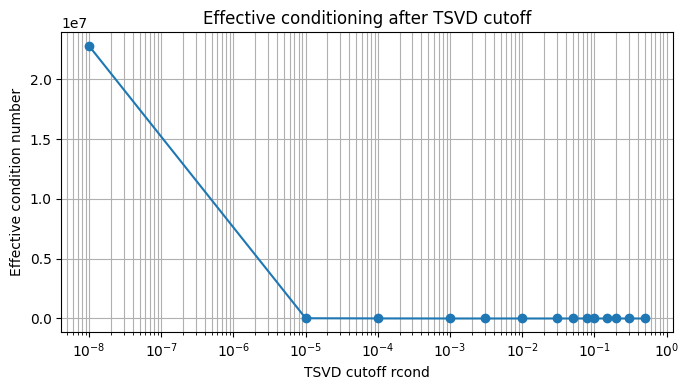

In [14]:
plt.figure(figsize=(7, 4))

plt.semilogx(
    rcond_values,
    cond_eff_tsvd,
    marker="o",
)

plt.xlabel("TSVD cutoff rcond")
plt.ylabel("Effective condition number")
plt.title("Effective conditioning after TSVD cutoff")
plt.grid(True, which="both")
plt.tight_layout()
plt.show()

### Effective Condition Number after TSVD Truncation

This plot shows the effective condition number of the truncated inverse problem as a function of the cutoff `rcond`.

Without meaningful truncation, the effective condition number is extremely large:

$$
\kappa_{\mathrm{eff}} \approx 2.28 \times 10^{7}.
$$

This means that small errors in the measured slopes can be strongly amplified in the reconstructed modal coefficients.

As `rcond` increases, the smallest retained singular values are removed. This strongly reduces the effective condition number. At the optimal cutoff

$$
\mathrm{rcond} = 5 \times 10^{-2},
$$

the effective condition number is reduced to approximately

$$
\kappa_{\mathrm{eff}} \approx 16.2.
$$

This is a dramatic improvement in numerical stability.

However, a smaller condition number is not automatically better. If `rcond` is too large, the reconstruction becomes numerically stable but loses too many physically useful modal directions. Therefore, the effective condition number must be interpreted together with the residual RMS and Strehl ratio.

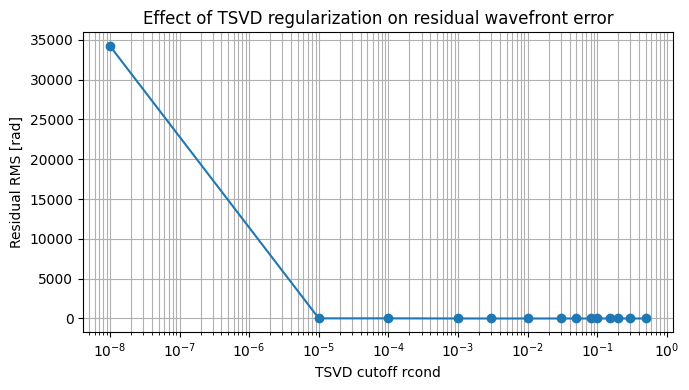

In [15]:
plt.figure(figsize=(7, 4))

plt.semilogx(
    rcond_values,
    residual_tsvd,
    marker="o",
)

plt.xlabel("TSVD cutoff rcond")
plt.ylabel("Residual RMS [rad]")
plt.title("Effect of TSVD regularization on residual wavefront error")
plt.grid(True, which="both")
plt.tight_layout()
plt.show()

### Residual RMS after TSVD-Regularized Reconstruction

This plot shows the residual wavefront RMS after TSVD-regularized reconstruction as a function of the cutoff `rcond`.

For extremely small cutoff values, the reconstruction keeps almost all singular directions, including very weak ones. This leads to severe noise amplification. At

$$
\mathrm{rcond} = 10^{-8},
$$

the residual RMS becomes extremely large, about

$$
34215 \ \mathrm{rad}.
$$

This is a clear signature of an unstable pseudo-inverse reconstruction.

As the cutoff is increased, the weakest singular directions are removed and the reconstruction becomes much more stable. The residual RMS decreases rapidly and reaches its minimum at

$$
\mathrm{rcond} = 5 \times 10^{-2}.
$$

At this optimal cutoff, the residual RMS is

$$
0.3762 \ \mathrm{rad}.
$$

For even larger cutoff values, the residual RMS increases again. This happens because the truncation becomes too aggressive and starts removing physically meaningful correction modes.

Therefore, the residual RMS curve demonstrates the central TSVD trade-off:

- too small `rcond`: unstable reconstruction and noise amplification;
- intermediate `rcond`: optimal noise suppression and wavefront correction;
- too large `rcond`: underfitting and loss of correction power.

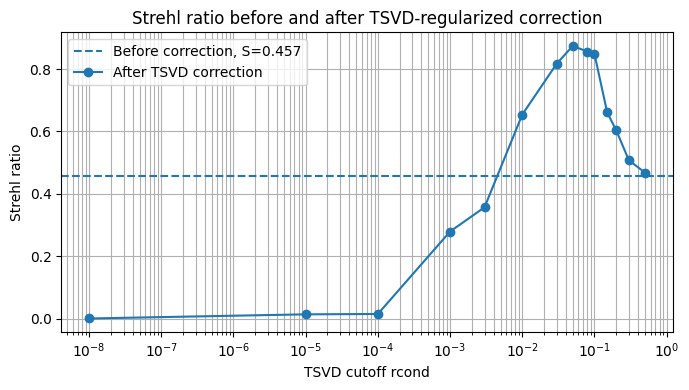

In [16]:
strehl_before = strehl_ratio(
    W_atm,
    mask,
    pad_factor=4,
)

plt.figure(figsize=(7, 4))

plt.axhline(
    strehl_before,
    linestyle="--",
    label=f"Before correction, S={strehl_before:.3f}",
)

plt.semilogx(
    rcond_values,
    strehl_tsvd,
    marker="o",
    label="After TSVD correction",
)

plt.xlabel("TSVD cutoff rcond")
plt.ylabel("Strehl ratio")
plt.title("Strehl ratio before and after TSVD-regularized correction")
plt.grid(True, which="both")
plt.legend()
plt.tight_layout()
plt.show()

### Strehl Ratio after TSVD-Regularized Correction

This plot shows the Strehl ratio before and after TSVD-regularized correction.

The dashed horizontal line shows the uncorrected Strehl ratio, which is approximately

$$
S \approx 0.457.
$$

For very small values of `rcond`, the corrected Strehl ratio is poor because the reconstruction is dominated by noise amplification from weak singular directions. At

$$
\mathrm{rcond} = 10^{-8},
$$

the Strehl ratio is only about

$$
S \approx 0.0003.
$$

As `rcond` increases, the weakest and most unstable singular directions are removed. The Strehl ratio then rises rapidly, showing that moderate TSVD regularization improves the optical correction.

The best performance is obtained at

$$
\mathrm{rcond} = 5 \times 10^{-2},
$$

where the Strehl ratio reaches

$$
S = 0.8741.
$$

At this point, 127 out of 152 singular directions are retained, the residual RMS is minimized, and the effective condition number is reduced to approximately 16.2.

For larger cutoff values, the Strehl ratio decreases again. This is the underfitting regime: too many useful modal directions are removed, so the correction becomes less accurate even though the inverse problem is numerically well conditioned.

The Strehl curve is therefore the clearest demonstration of the TSVD regularization optimum. The best optical image quality is achieved not by keeping all singular directions, but by choosing an intermediate cutoff that balances noise suppression against modal correction accuracy.

In [17]:
best_idx_strehl = np.argmax(strehl_tsvd)
best_idx_rms = np.argmin(residual_tsvd)

print("Best TSVD cutoff based on Strehl ratio")
print("--------------------------------------")
print(f"best rcond:       {rcond_values[best_idx_strehl]:.2e}")
print(f"kept directions:  {n_kept_tsvd[best_idx_strehl]}/{tsvd_results[best_idx_strehl]['info']['n_total']}")
print(f"residual RMS:     {residual_tsvd[best_idx_strehl]:.4f} rad")
print(f"Strehl ratio:     {strehl_tsvd[best_idx_strehl]:.4f}")
print(f"effective cond:   {cond_eff_tsvd[best_idx_strehl]:.2e}")

print()

print("Best TSVD cutoff based on residual RMS")
print("--------------------------------------")
print(f"best rcond:       {rcond_values[best_idx_rms]:.2e}")
print(f"kept directions:  {n_kept_tsvd[best_idx_rms]}/{tsvd_results[best_idx_rms]['info']['n_total']}")
print(f"residual RMS:     {residual_tsvd[best_idx_rms]:.4f} rad")
print(f"Strehl ratio:     {strehl_tsvd[best_idx_rms]:.4f}")
print(f"effective cond:   {cond_eff_tsvd[best_idx_rms]:.2e}")

Best TSVD cutoff based on Strehl ratio
--------------------------------------
best rcond:       5.00e-02
kept directions:  127/152
residual RMS:     0.3762 rad
Strehl ratio:     0.8741
effective cond:   1.62e+01

Best TSVD cutoff based on residual RMS
--------------------------------------
best rcond:       5.00e-02
kept directions:  127/152
residual RMS:     0.3762 rad
Strehl ratio:     0.8741
effective cond:   1.62e+01


### Best TSVD Cutoff

The optimal cutoff is found consistently from both the maximum Strehl ratio and the minimum residual RMS.

The best value is

$$
\mathrm{rcond} = 5 \times 10^{-2}.
$$

At this cutoff, the reconstruction keeps

$$
127 / 152
$$

singular directions. The corresponding performance is

$$
\mathrm{Residual\ RMS} = 0.3762 \ \mathrm{rad},
$$

$$
S = 0.8741,
$$

and

$$
\kappa_{\mathrm{eff}} = 16.2.
$$

This result shows that the optimal TSVD cutoff removes a moderate number of weak singular directions while preserving most of the physically useful modal information.

Compared with the weak-cutoff case, the improvement is dramatic: the reconstruction changes from being dominated by numerical noise amplification to producing a high-Strehl corrected wavefront.

Compared with the strong-cutoff case, the optimal cutoff still retains enough degrees of freedom to avoid underfitting the atmospheric phase.

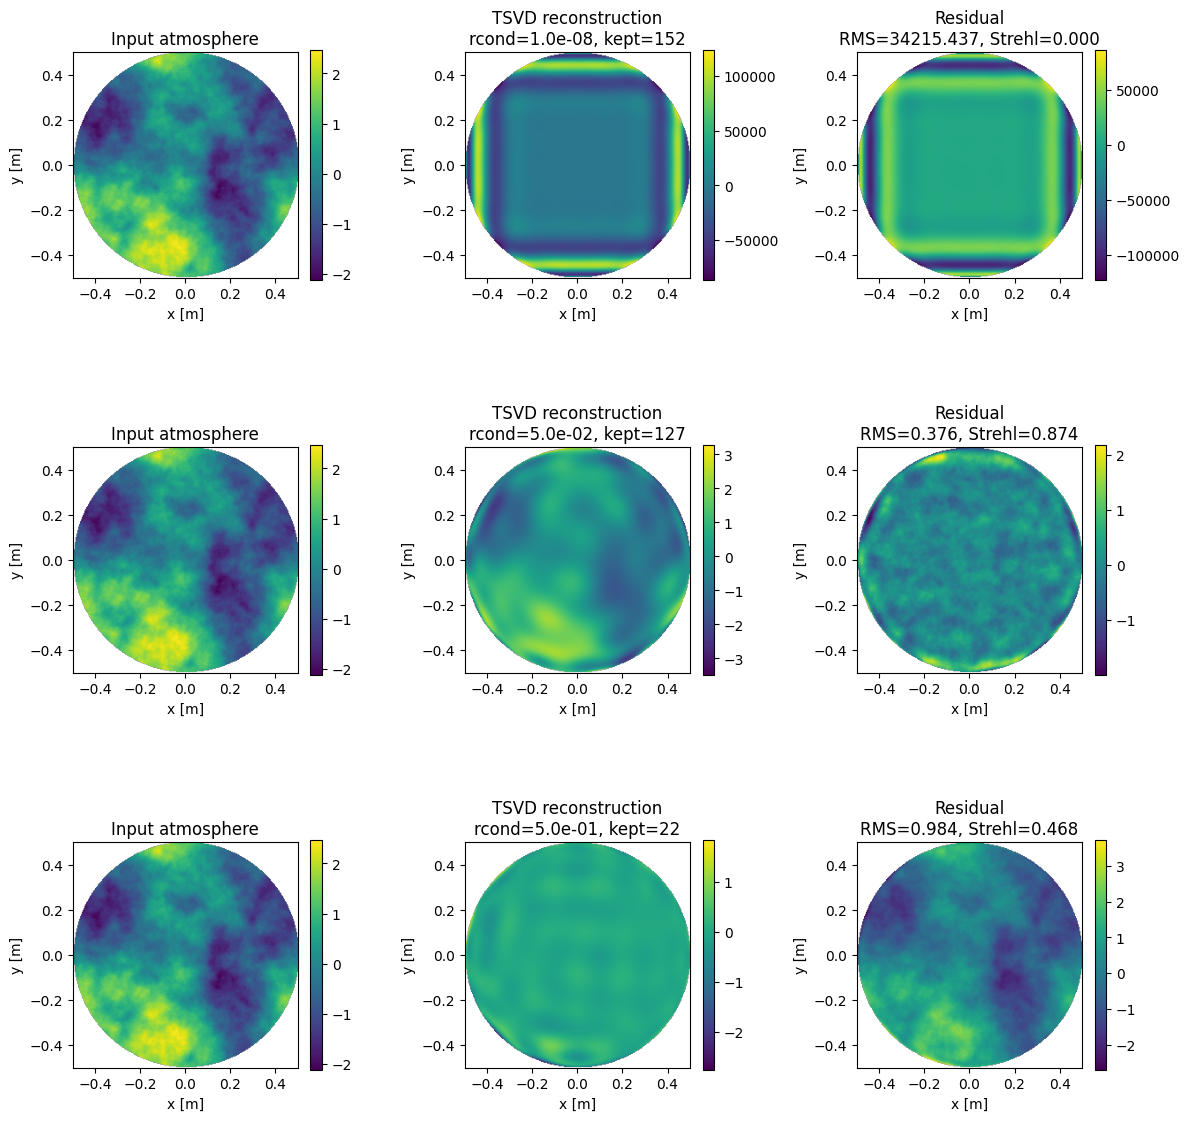

In [18]:
selected_rconds = [
    rcond_values[0],
    rcond_values[len(rcond_values) // 2],
    rcond_values[-1],
]

selected_indices = [
    np.where(rcond_values == r)[0][0] for r in selected_rconds
]

fig, axes = plt.subplots(
    len(selected_indices),
    3,
    figsize=(12, 4 * len(selected_indices)),
)

for row, idx in enumerate(selected_indices):
    result = tsvd_results[idx]
    rcond = rcond_values[idx]

    W_rec = result["W_rec"]
    res = result["residual"]

    im0 = axes[row, 0].imshow(
        W_atm,
        extent=extent,
        origin="lower",
    )
    axes[row, 0].set_title("Input atmosphere")
    axes[row, 0].set_xlabel("x [m]")
    axes[row, 0].set_ylabel("y [m]")
    plt.colorbar(im0, ax=axes[row, 0], fraction=0.046)

    im1 = axes[row, 1].imshow(
        W_rec,
        extent=extent,
        origin="lower",
    )
    axes[row, 1].set_title(
        f"TSVD reconstruction\n"
        f"rcond={rcond:.1e}, kept={result['info']['n_kept']}"
    )
    axes[row, 1].set_xlabel("x [m]")
    axes[row, 1].set_ylabel("y [m]")
    plt.colorbar(im1, ax=axes[row, 1], fraction=0.046)

    im2 = axes[row, 2].imshow(
        res,
        extent=extent,
        origin="lower",
    )
    axes[row, 2].set_title(
        f"Residual\n"
        f"RMS={result['residual_rms']:.3f}, Strehl={result['strehl']:.3f}"
    )
    axes[row, 2].set_xlabel("x [m]")
    axes[row, 2].set_ylabel("y [m]")
    plt.colorbar(im2, ax=axes[row, 2], fraction=0.046)

plt.tight_layout()
plt.show()

### Wavefront Reconstruction Maps for Different TSVD Cutoffs

These maps compare the input atmospheric phase, the TSVD-reconstructed wavefront, and the residual phase for representative cutoff values.

For the weakest cutoff, almost all singular directions are retained. Because the response matrix is highly ill-conditioned, the reconstruction is contaminated by noise-amplified components. The reconstructed wavefront can contain large unphysical structures, leading to a very large residual RMS and a poor Strehl ratio.

For the intermediate cutoff, the weakest singular directions are suppressed while most of the useful modal information is retained. This produces the best reconstruction: the dominant atmospheric structures are corrected, the residual phase is minimized, and the Strehl ratio reaches its maximum.

For the strongest cutoff, the reconstruction becomes too restrictive. Although the inverse problem is numerically stable, too many modal directions have been discarded. The reconstructed wavefront becomes underfit, leaving significant uncorrected residual structure across the pupil.

These maps provide a spatial interpretation of the TSVD trade-off. The optimal cutoff does not simply produce the smoothest reconstruction; it produces the best balance between suppressing unstable modes and retaining enough spatial complexity to correct the atmospheric wavefront.

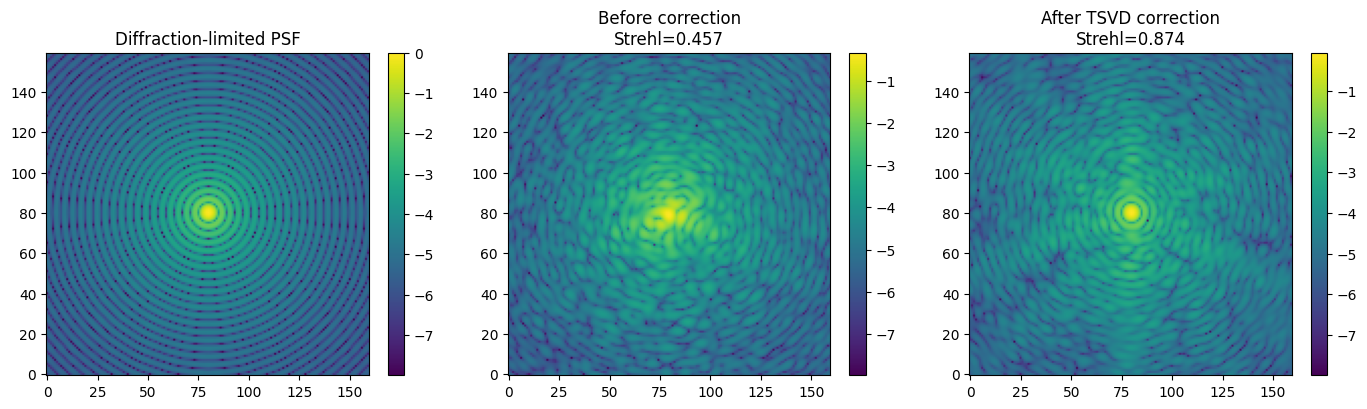

In [19]:
best_result = tsvd_results[best_idx_strehl]

psf_ideal = compute_psf_from_phase(
    np.zeros_like(W_atm),
    mask,
    pad_factor=4,
)

psf_before = compute_psf_from_phase(
    W_atm,
    mask,
    pad_factor=4,
)

psf_after = compute_psf_from_phase(
    best_result["residual"],
    mask,
    pad_factor=4,
)

reference_peak = np.max(psf_ideal)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

crop = 80
center = psf_ideal.shape[0] // 2
sl = slice(center - crop, center + crop)

im0 = axes[0].imshow(
    np.log10(psf_ideal[sl, sl] / reference_peak + 1e-8),
    origin="lower",
)
axes[0].set_title("Diffraction-limited PSF")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(
    np.log10(psf_before[sl, sl] / reference_peak + 1e-8),
    origin="lower",
)
axes[1].set_title(f"Before correction\nStrehl={strehl_before:.3f}")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(
    np.log10(psf_after[sl, sl] / reference_peak + 1e-8),
    origin="lower",
)
axes[2].set_title(
    f"After TSVD correction\n"
    f"Strehl={best_result['strehl']:.3f}"
)
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()

### PSF Comparison before and after Correction

The PSF comparison translates the wavefront reconstruction quality into image-plane performance.

The ideal diffraction-limited PSF shows the reference case with no wavefront aberration. The uncorrected atmospheric phase spreads light away from the diffraction-limited core and reduces the Strehl ratio.

After TSVD-regularized correction at the optimal cutoff, the PSF core becomes much brighter and more concentrated. This corresponds to the maximum Strehl ratio obtained in the cutoff scan:

$$
S = 0.8741.
$$

The log-scale PSF panels are especially useful for comparing the halo structure. They show that the optimal TSVD correction not only improves the central peak, but also suppresses part of the aberration-induced halo.

This figure gives the optical meaning of the regularization result: choosing an appropriate TSVD cutoff directly improves image quality by preventing noise-amplified wavefront reconstruction errors from degrading the corrected PSF.

## Overall Interpretation of the TSVD Regularization Test

This notebook demonstrates how truncated singular value decomposition regularization affects modal Shack-Hartmann wavefront reconstruction in an intentionally challenging, ill-conditioned setup.

The response matrix has 152 singular values, but its smallest normalized singular value is only

$$
4.39 \times 10^{-8},
$$

giving a condition number of approximately

$$
2.28 \times 10^{7}.
$$

This means that a direct pseudo-inverse reconstruction is highly unstable. Very weak singular directions can amplify slope-measurement noise into extremely large errors in the reconstructed wavefront.

The TSVD scan shows three distinct regimes.

First, for very small cutoff values, almost all singular directions are retained. This includes weak, noise-sensitive directions. The reconstruction is therefore dominated by noise amplification. The residual RMS can become extremely large, and the Strehl ratio remains very poor.

Second, for intermediate cutoff values, TSVD removes the weakest singular directions while keeping the dominant physical correction modes. This is the useful regularization regime. The residual RMS decreases, the effective condition number becomes much smaller, and the Strehl ratio increases.

The best performance is obtained at

$$
\mathrm{rcond} = 5 \times 10^{-2}.
$$

At this cutoff, 127 out of 152 singular directions are retained, the residual RMS reaches

$$
0.3762 \ \mathrm{rad},
$$

and the Strehl ratio reaches

$$
S = 0.8741.
$$

Third, for very large cutoff values, too many singular directions are removed. Although the inverse problem becomes numerically very stable, the reconstruction loses physical correction power. The residual RMS increases again and the Strehl ratio decreases. This is the underfitting regime.

The main conclusion is that TSVD regularization is not simply about using the largest possible or smallest possible number of modes. Instead, the cutoff must balance two competing effects:

- keeping too many weak singular directions causes noise amplification;
- removing too many singular directions causes modal underfitting.

The optimal cutoff lies between these two extremes.

In the context of a real Shack-Hartmann WFS, the slope noise would originate from detector-level effects such as photon noise, read noise, background, finite pixel sampling, spot truncation, and centroiding errors. These errors enter the modal reconstruction through the measured slopes. TSVD regularization prevents weakly sensed modal directions from converting such measurement noise into large wavefront reconstruction errors.

Therefore, this notebook demonstrates the practical role of TSVD as a regularized inverse method for adaptive-optics wavefront reconstruction: it improves the final corrected wavefront and PSF only when the inverse problem contains weak, noise-dominated singular directions.